In [21]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

In [25]:
from google.colab import files
upload = files.upload()

Saving creditcard.csv to creditcard.csv


In [26]:
data = pd.read_csv('creditcard.csv',sep=',')
data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [28]:
data.isnull().values.any()

np.False_

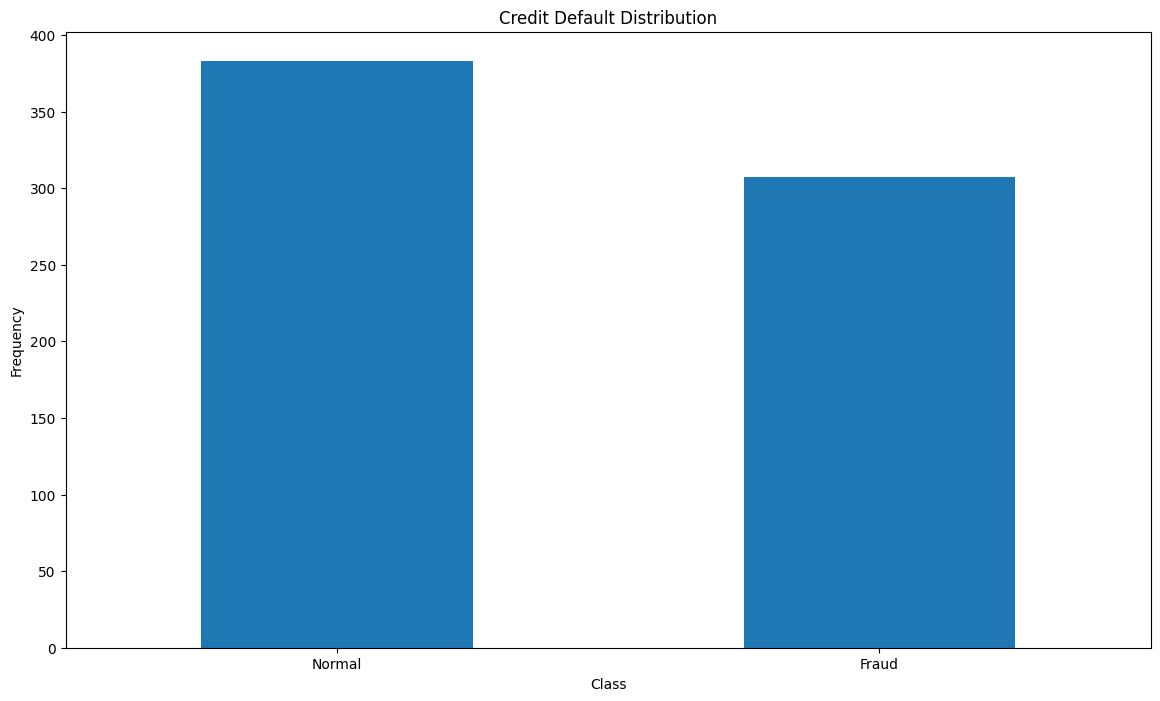

In [30]:
count_classes = data['Class'].value_counts().sort_index()
count_classes.plot(kind='bar', rot=0)
plt.title("Credit Default Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

In [32]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0]

print("Default records:", fraud.shape)
print("Non-default records:", normal.shape)

Default records: (307, 16)
Non-default records: (383, 16)


In [34]:
fraud.A14.describe()

,A14
count,307.000000
mean,2039.859935
std,7659.763941
min,1.000000
25%,1.000000
50%,222.000000
75%,1210.000000
max,100001.000000


In [36]:
normal.A14.describe()

,A14
count,383.000000
mean,199.605744
std,671.608839
min,1.000000
25%,1.000000
50%,2.000000
75%,68.000000
max,5553.000000


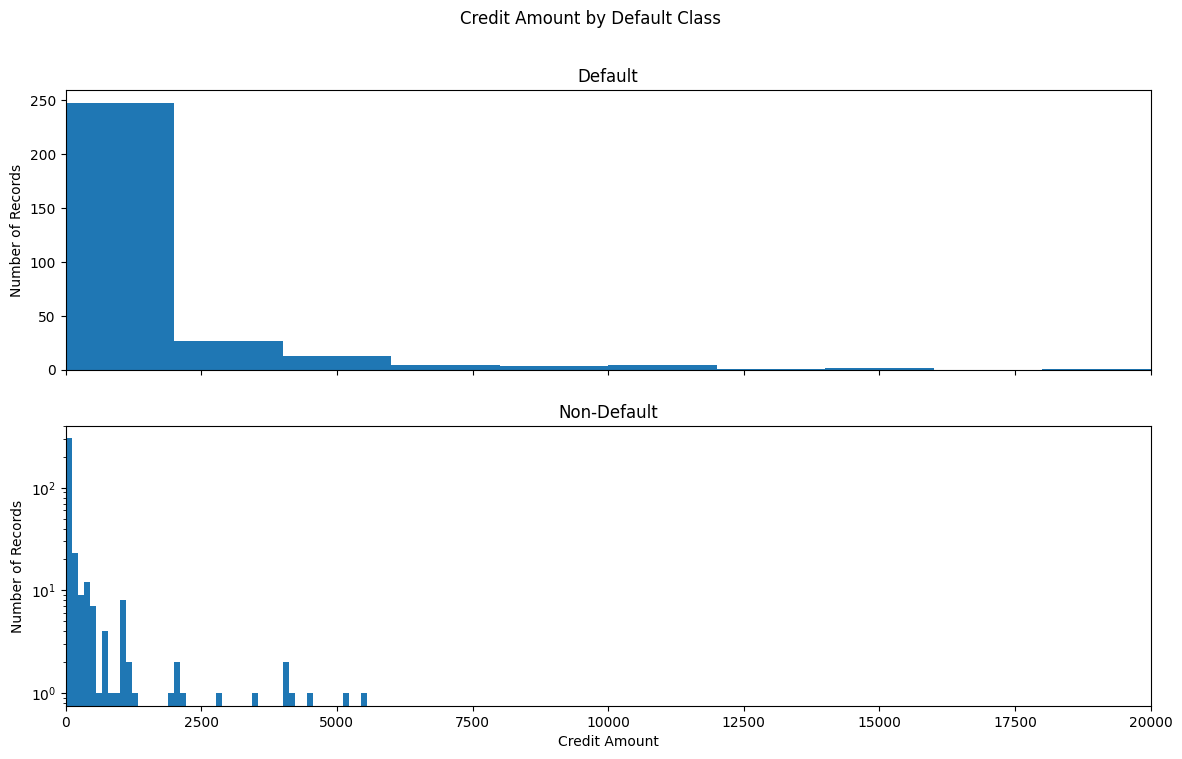

In [38]:
import matplotlib.pyplot as plt

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

f.suptitle('Credit Amount by Default Class')

bins = 50

ax1.hist(fraud['A14'], bins=bins)
ax1.set_title('Default')

ax2.hist(normal['A14'], bins=bins)
ax2.set_title('Non-Default')

ax2.set_xlabel('Credit Amount')
ax1.set_ylabel('Number of Records')
ax2.set_ylabel('Number of Records')

plt.xlim((0, 20000))
plt.yscale('log')

plt.show()

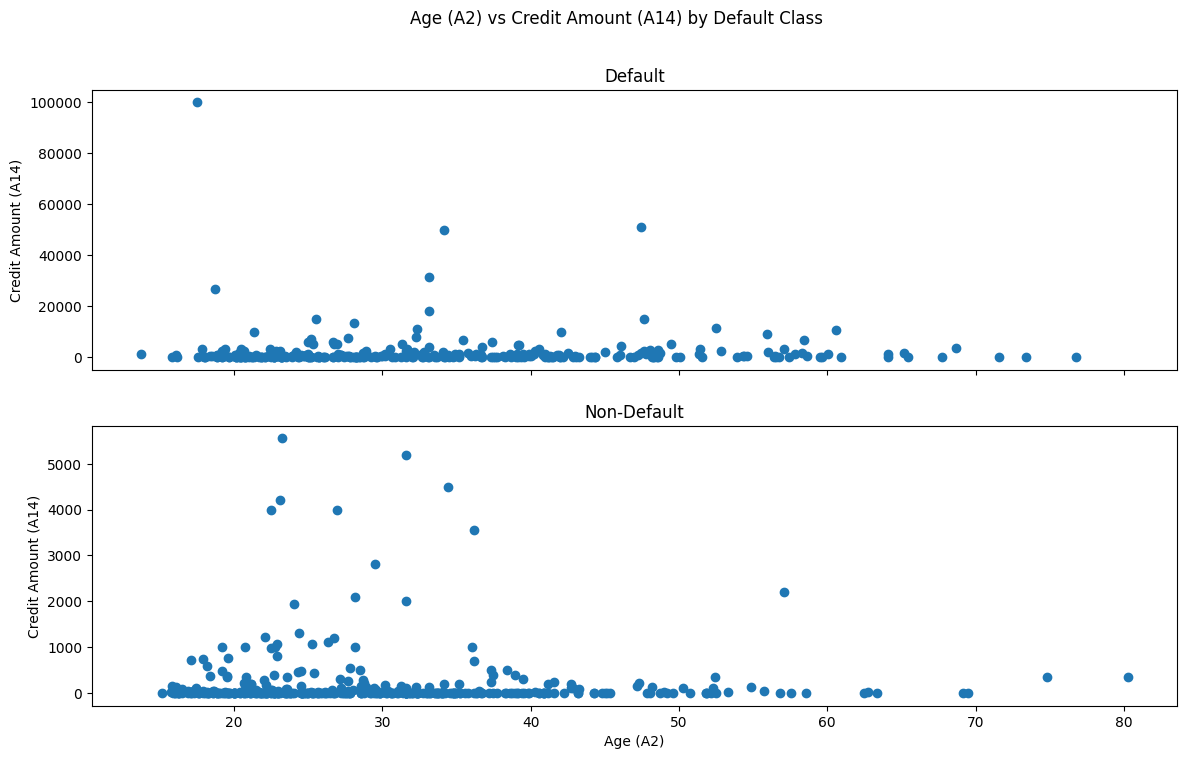

In [40]:
import matplotlib.pyplot as plt

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

f.suptitle('Age (A2) vs Credit Amount (A14) by Default Class')

ax1.scatter(fraud['A2'], fraud['A14'])
ax1.set_title('Default')

ax2.scatter(normal['A2'], normal['A14'])
ax2.set_title('Non-Default')

ax2.set_xlabel('Age (A2)')
ax1.set_ylabel('Credit Amount (A14)')
ax2.set_ylabel('Credit Amount (A14)')

plt.show()

In [41]:
data = data.sample(frac=0.1, random_state=1)
print(data.shape)

(69, 16)


In [43]:
fraud_sampled = data[data['Class'] == 1]
normal_sampled = data[data['Class'] == 0]

outlier_fraction = len(fraud_sampled) / float(len(normal_sampled))

print("Outlier Fraction:", outlier_fraction)
print("Default Cases:", len(fraud_sampled))
print("Non-Default Cases:", len(normal_sampled))

Outlier Fraction: 1.2258064516129032
Default Cases: 38
Non-Default Cases: 31


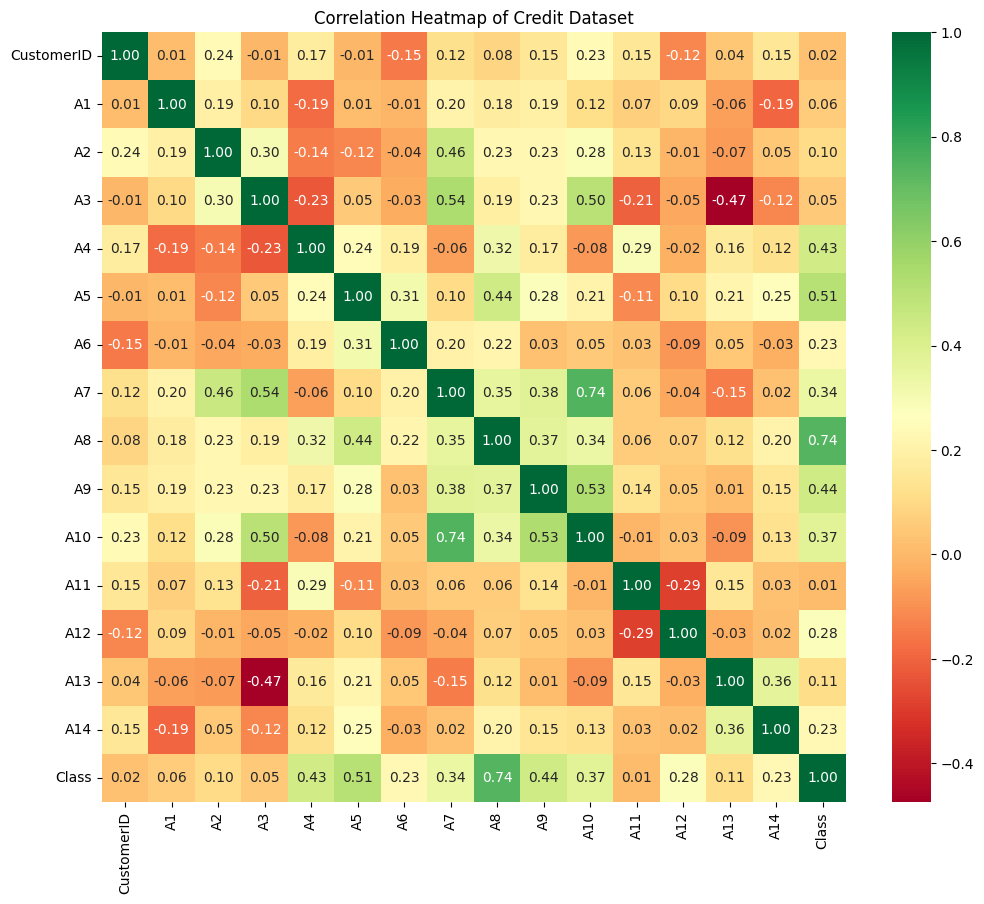

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_data = data.select_dtypes(include=['number'])

# Get correlations
corrmat = numeric_data.corr()

# Get feature names
top_corr_features = corrmat.index

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corrmat,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Credit Dataset")
plt.show()

In [46]:
import numpy as np
import pandas as pd

# Define target
target = "Class"

# Separate input features and target
X = data.drop(columns=[target])
Y = data[target]

# Convert categorical columns into numerical values
X = pd.get_dummies(X, drop_first=True)

# Define random state
state = np.random.RandomState(42)

# Create random outlier data
X_outliers = state.uniform(
    low=0,
    high=1,
    size=(X.shape[0], X.shape[1])
)

# Print shapes
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("X_outliers shape:", X_outliers.shape)

X shape: (69, 15)
Y shape: (69,)
X_outliers shape: (69, 15)


In [49]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, classification_report

# Calculate outlier proportion in the sampled data
fraud_sampled = data[data['Class'] == 1]
normal_sampled = data[data['Class'] == 0]

total_sampled = len(fraud_sampled) + len(normal_sampled)
outlier_proportion_in_sample = len(fraud_sampled) / float(total_sampled)

print("Actual Outlier Proportion in Sampled Data (Class 1 / Total):", outlier_proportion_in_sample)
print("Default Cases:", len(fraud_sampled))
print("Non-Default Cases:", len(normal_sampled))

# Contamination parameter for IsolationForest and LOF must be <= 0.5
# If the actual proportion of fraud in the sample is > 0.5, we cap it at 0.5
contamination_param = min(outlier_proportion_in_sample, 0.5)

print(f"Using contamination parameter for IsolationForest/LOF: {contamination_param:.4f} (capped at 0.5 if actual proportion > 0.5)")

# Define classifiers
classifiers = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        max_samples=len(X),
        contamination=contamination_param,
        random_state=42,
        verbose=0
    ),

    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        algorithm='auto',
        leaf_size=30,
        metric='minkowski',
        p=2,
        metric_params=None,
        contamination=contamination_param
    )
}

# Number of actual default cases
n_outliers = len(fraud_sampled)

# Apply classifiers
for clf_name, clf in classifiers.items():

    print("\n" + "=" * 50)
    print(clf_name)
    print("=" * 50)

    # Local Outlier Factor
    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
        scores_prediction = clf.negative_outlier_factor_

    # Isolation Forest
    else:
        clf.fit(X)
        scores_prediction = clf.decision_function(X)
        y_pred = clf.predict(X)

    # Convert predictions:
    # 1  → Non-Default
    # -1 → Default
    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1

    # Calculate errors
    n_errors = (y_pred != Y).sum()

    print("Number of Errors:", n_errors)

    # Accuracy
    print("\nAccuracy Score:")
    print(accuracy_score(Y, y_pred))

    # Classification report
    print("\nClassification Report:")
    print(classification_report(Y, y_pred))

Actual Outlier Proportion in Sampled Data (Class 1 / Total): 0.5507246376811594
Default Cases: 38
Non-Default Cases: 31
Using contamination parameter for IsolationForest/LOF: 0.5000 (capped at 0.5 if actual proportion > 0.5)

Isolation Forest
Number of Errors: 38

Accuracy Score:
0.4492753623188406

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.45      0.42        31
           1       0.50      0.45      0.47        38

    accuracy                           0.45        69
   macro avg       0.45      0.45      0.45        69
weighted avg       0.46      0.45      0.45        69


Local Outlier Factor
Number of Errors: 36

Accuracy Score:
0.4782608695652174

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.48      0.45        31
           1       0.53      0.47      0.50        38

    accuracy                           0.48        69
   macro avg       0.48     